
## Title: Policy and Flow

## Headline 1: Inflation and Unemployment as Push Factors

In [12]:
import pandas as pd

# Load dataset (skip metadata rows)
infl = pd.read_csv("/Users/zaangwenya/Documents/finalised_data_science_lab/DataScienceLab_Migration/data_raw/Inflation Consumer Prices.csv", skiprows=4)

# Keep only Nigeria
infl_ng = infl[infl["Country Name"] == "Nigeria"]

# Drop unnecessary columns
infl_ng = infl_ng.drop(columns=["Country Code", "Indicator Name", "Indicator Code"])

# Convert from wide → long format
infl_long = infl_ng.melt(
    id_vars=["Country Name"],
    var_name="Year",
    value_name="Inflation"
)

# Clean data
infl_long["Year"] = pd.to_numeric(infl_long["Year"], errors="coerce")
infl_long["Inflation"] = pd.to_numeric(infl_long["Inflation"], errors="coerce")

# Remove missing values
infl_long = infl_long.dropna()

infl_long = infl_long[infl_long["Year"] >= 2000]

# Sort by year
infl_long = infl_long.sort_values("Year")

# Save clean file
infl_long.to_csv("nigeria_inflation_clean.csv", index=False)

print(infl_long.head())

   Country Name    Year  Inflation
40      Nigeria  2000.0   6.933292
41      Nigeria  2001.0  18.873646
42      Nigeria  2002.0  12.876579
43      Nigeria  2003.0  14.031784
44      Nigeria  2004.0  14.998034


⬆:This script cleans Nigerian inflation data for easier analysis. It removes unnecessary metadata and reshapes the dataset from wide to long format using the melt function ensuring all values are numeric. It also filters the data from the year 2000 onwards and sorts it chronologically. The same cleaning approach can also be applied to unemployment and labor force datasets since they come from the same source(The World Bank).

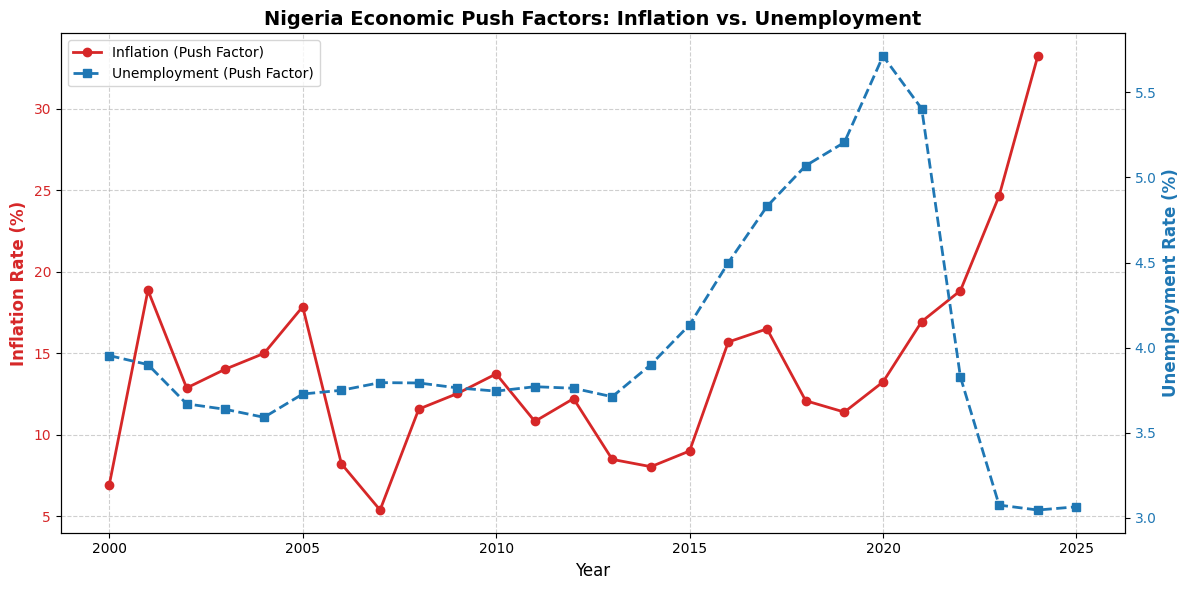

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the data from your CSV files
# Ensure the file names below match your actual filenames exactly
try:
    df_inf = pd.read_csv('/Users/zaangwenya/Documents/finalised_data_science_lab/DataScienceLab_Migration/data_processed/clean_in.csv')
    df_unemp = pd.read_csv('/Users/zaangwenya/Documents/finalised_data_science_lab/DataScienceLab_Migration/data_processed/clean_un.csv')
except FileNotFoundError:
    print("Error: Ensure your CSV files are in the same folder as this script.")

# 2. Setup the figure and the first axis (Inflation)
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Inflation (Primary Y-Axis)
color_inf = 'tab:red'
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Inflation Rate (%)', color=color_inf, fontsize=12, fontweight='bold')
ax1.plot(df_inf['Year'], df_inf['Inflation Rate'], color=color_inf, marker='o', label='Inflation (Push Factor)', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color_inf)
ax1.grid(True, linestyle='--', alpha=0.6)

# 3. Setup the second axis (Unemployment)
ax2 = ax1.twinx()
color_unemp = 'tab:blue'
ax2.set_ylabel('Unemployment Rate (%)', color=color_unemp, fontsize=12, fontweight='bold')
ax2.plot(df_unemp['Year'], df_unemp['Unemployment Rate'], color=color_unemp, marker='s', label='Unemployment (Push Factor)', linewidth=2, linestyle='--')
ax2.tick_params(axis='y', labelcolor=color_unemp)

# 4. Final touches
plt.title('Nigeria Economic Push Factors: Inflation vs. Unemployment', fontsize=14, fontweight='bold')
fig.tight_layout()

# Add a combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

# 5. Display the graph
plt.show()


⬆:This graph visualizes the relationship between Nigeria's Inflation Rate (red solid line) and Unemployment Rate (blue dashed line) from 2000 to 2025. It employs a dual-axis design to manage the different scales of the two metrics, with inflation measured on the left axis and unemployment on the right.


For the first fifteen years (2000–2015), both indicators fluctuated within a relatively stable range. Inflation generally stayed between 5% and 20% while unemployment remained low and steady, hovering near 4%. However, the period after 2015 marks a significant shift in economic stability. Unemployment saw a dramatic surge, peaking at nearly 5.8% around 2020 due to Covid before experiencing a sharp decline toward 3% by 2023.


In contrast, inflation has followed an aggressive upward trajectory in recent years. While it dipped slightly around 2020, it skyrocketed after 2021, breaking past 30% by 2024. This creates a striking divergence in the final years of the plot as unemployment figures appear to have stabilized at a historic low, inflation has surged to a historic high, suggesting that soaring costs of living have replaced job availability as the primary economic "push factor" for the country.

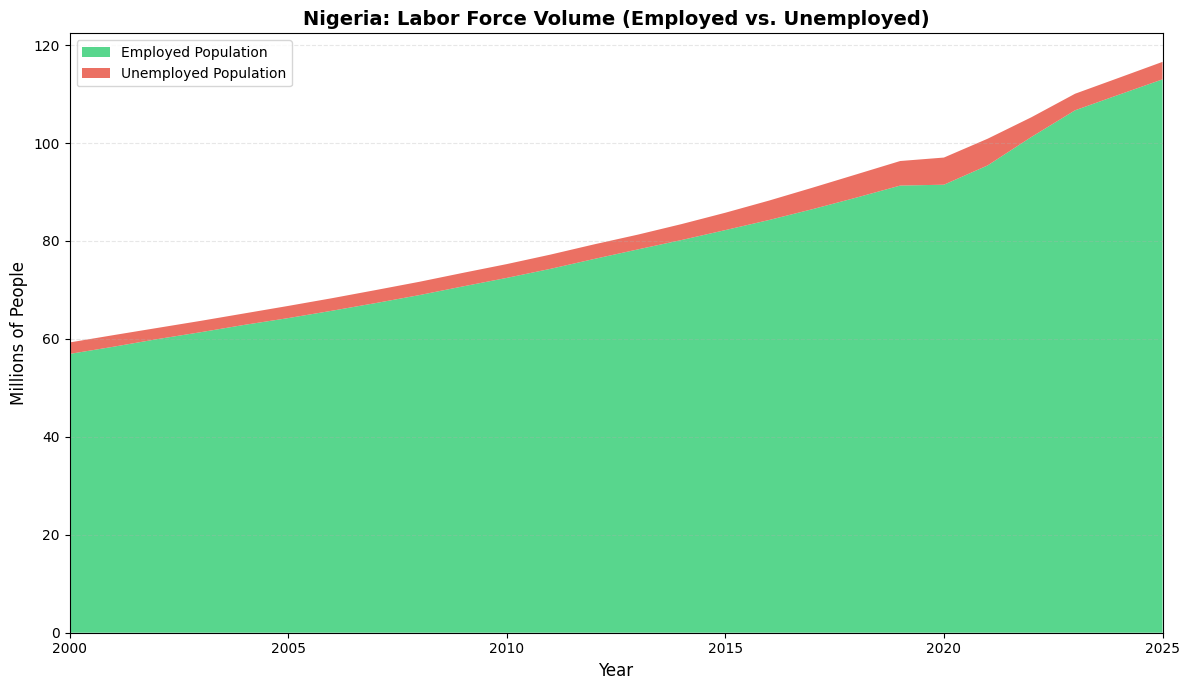

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load Labor Force data
df_total = pd.read_csv('/Users/zaangwenya/Documents/finalised_data_science_lab/DataScienceLab_Migration/data_processed/clean_labor_force.csv')
df_total.columns = df_total.columns.str.strip()  # remove extra spaces

# Filter for Nigeria
df_ng_total = df_total[df_total['Country Name'] == 'Nigeria'].copy()

# Ensure 'Year' is numeric
df_ng_total['Year'] = pd.to_numeric(df_ng_total['Year'])

# 2. Load Unemployment Rate data
df_unemp = pd.read_csv('/Users/zaangwenya/Documents/finalised_data_science_lab/DataScienceLab_Migration/data_processed/clean_un.csv')
df_unemp.columns = df_unemp.columns.str.strip()
df_unemp['Year'] = pd.to_numeric(df_unemp['Year'])

# 3. Merge datasets on 'Year'
df_combined = pd.merge(df_ng_total, df_unemp, on='Year')

# 4. Calculate Employed and Unemployed counts
df_combined['Unemployed_Count'] = (df_combined['Unemployment Rate'] / 100) * df_combined['Total_Labor_Force']
df_combined['Employed_Count'] = df_combined['Total_Labor_Force'] - df_combined['Unemployed_Count']

# 5. Plot Stacked Area Chart
plt.figure(figsize=(12, 7))

plt.stackplot(
    df_combined['Year'],
    df_combined['Employed_Count'] / 1e6,
    df_combined['Unemployed_Count'] / 1e6,
    labels=['Employed Population', 'Unemployed Population'],
    colors=['#2ecc71', '#e74c3c'],
    alpha=0.8
)

plt.title('Nigeria: Labor Force Volume (Employed vs. Unemployed)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Millions of People', fontsize=12)
plt.xlim(df_combined['Year'].min(), df_combined['Year'].max())
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

⬆:This stacked area chart provides a comprehensive look at Nigeria's growing labor force from 2000 to 2025, but its visual representation of employment (the green area) requires a critical economic lens to understand the reality on the ground. At a glance, the total labor force shows a massive, steady expansion, nearly doubling from 60 million to over 110 million people, which illustrates the country's significant demographic youth bulge. While the red area representing unemployment appears to shrink significantly after 2020, this trend is largely a reflection of a controversial shift in data methodology rather than a sudden abundance of high quality jobs.


The sharp drop in the red unemployed section corresponds with the 1-hour working rule adopted by the National Bureau of Statistics (NBS) in 2023 to align with International Labour Organization (ILO) standards. Under this definition, anyone who engages in at least one hour of economic activity for pay or profit in the preceding seven days is classified as "employed". This includes everything from small scale trade and subsistence farming to running minor errands. Consequently, the vast green area on the chart masks a deep seated crisis of underemployment and working poverty, where millions are technically employed but earn far too little to survive amidst Nigeria's triple digit inflation and a depreciated Naira.


This disconnect between statistical employment and economic stability is the primary driver of the "Japa" phenomenon, where skilled and unskilled Nigerians alike seek work elsewhere. Even though the chart shows a large employed population, the economy remains volatile due to soaring fuel prices, a high misery index, and a cost of living crisis that has outpaced the new minimum wage. For many represented in that green area, employment does not mean a stable career or financial security, instead, it represents a survival struggle that pushes them to look for better opportunities beyond Nigeria's borders.


## Part 1B: UK Immigration Policy and Migration of Nigerian Healthcare Workers

### 1. Objective

This section examines whether UK immigration policy acts as a pull factor influencing the migration of Nigerian healthcare professionals.

Specifically, it evaluates the relationship between changes in UK policy openness and observed trends in the migration of Nigerian healthcare workers to the UK. This contributes to the broader group objective of understanding how migration policy and macro-level conditions shape healthcare worker mobility.

### 2. Data and Methodology

This analysis combines two datasets:

- UK immigration policy data from the DEMIG/MIGPOL database
- Nigerian healthcare worker migration data

To quantify the policy environment, a cumulative policy index is constructed. Liberalizing policies are coded as +1, while restrictive policies are coded as -1. The cumulative index captures the overall direction of UK migration policy over time.

To align with the wider group project, the datasets are compared at selected time intervals. Variables are also standardized using z-scores to enable meaningful comparison between policy trends and healthcare migration flows.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Optional display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# =========================
# FILE PATHS
# =========================
# Replace only if needed

policy_file = r"C:\Users\judit\DataScienceLab_Migration\data_raw\complab_migpol_demig_quantmig_cleaned.csv"
medical_file = r"C:\Users\judit\DataScienceLab_Migration\data_processed\nigeria_migrant_totals(Totals).csv"

print("Policy file exists:", os.path.exists(policy_file))
print("Medical file exists:", os.path.exists(medical_file))

# =========================
# LOAD DATA
# =========================
policy_raw = pd.read_csv(policy_file, encoding="latin1")
medical_raw = pd.read_csv(medical_file)

print("Policy data shape:", policy_raw.shape)
print("Medical data shape:", medical_raw.shape)

print("\nPolicy columns:")
print(policy_raw.columns.tolist())

print("\nMedical columns:")
print(medical_raw.columns.tolist())

Policy file exists: True
Medical file exists: True
Policy data shape: (9051, 18)
Medical data shape: (6, 2)

Policy columns:
['year', 'iso2', 'change_id', 'iso3', 'country_full_name', 'summary', 'change_mag', 'change_level', 'pol_area', 'pol_tool', 'target_group', 'target_origin', 'target_specific', 'change_restrict', 'u_complab_country_year_change_country', 'u_complab_country_year_change_country_code', 'u_complab_country_year_change_year', 'u_complab_country_year_change_change']

Medical columns:
['Year', 'Total Migrants']


### 3. Data Processing

The datasets are first cleaned and filtered to focus on UK-specific immigration policy changes and Nigerian healthcare migration data.

A cumulative policy index is then created, and both datasets are aligned to comparable time points. Standardization is used to compare the policy trend and migration trend on the same scale.

In [18]:
# =========================
# CLEAN POLICY DATA
# =========================

policy_df = policy_raw.copy()

# Clean country names
policy_df["country_full_name"] = policy_df["country_full_name"].astype(str).str.strip()

# Filter for UK only
policy_uk = policy_df[policy_df["country_full_name"] == "United Kingdom"].copy()

print("UK policy rows:", policy_uk.shape[0])

# Make sure numeric
policy_uk["change_restrict"] = pd.to_numeric(policy_uk["change_restrict"], errors="coerce")
policy_uk["year"] = pd.to_numeric(policy_uk["year"], errors="coerce")

# Keep only clearly restrictive/liberalizing policy changes
policy_uk = policy_uk[policy_uk["change_restrict"].isin([-1.0, 1.0])].copy()

print("\nPolicy direction counts:")
print(policy_uk["change_restrict"].value_counts())

# =========================
# BUILD POLICY INDEX
# =========================

# Reverse sign so:
# +1 = more open / liberalizing
# -1 = more restrictive
policy_uk["policy_signed"] = -policy_uk["change_restrict"]

policy_year = (
    policy_uk.groupby("year", as_index=False)["policy_signed"]
    .sum()
    .rename(columns={"policy_signed": "PolicyChange"})
)

policy_year["PolicyIndex"] = policy_year["PolicyChange"].cumsum()

# Fill missing years for continuity
full_years = pd.DataFrame({"year": range(2000, 2027)})
policy_year = full_years.merge(policy_year, on="year", how="left")
policy_year["PolicyChange"] = policy_year["PolicyChange"].fillna(0)
policy_year["PolicyIndex"] = policy_year["PolicyIndex"].ffill()
policy_year["PolicyIndex"] = policy_year["PolicyIndex"].fillna(0)

print("\nPolicy index preview:")
print(policy_year.head(10))
print(policy_year.tail(10))

# =========================
# CLEAN HEALTHCARE MIGRATION DATA
# =========================
# NOTE:
# The file column is labelled "Total Migrants", but for this project
# it is being treated as pre-filtered Nigerian medical personnel data.

medical_df = medical_raw.copy()
medical_df.columns = [c.strip() for c in medical_df.columns]

print("\nHealthcare migration columns detected:")
print(medical_df.columns.tolist())

year_col = "Year"
migration_col = "Total Migrants"

healthcare_df = medical_df[[year_col, migration_col]].copy()
healthcare_df.columns = ["year", "HealthcareMigration"]

healthcare_df["year"] = pd.to_numeric(healthcare_df["year"], errors="coerce")
healthcare_df["HealthcareMigration"] = pd.to_numeric(healthcare_df["HealthcareMigration"], errors="coerce")

healthcare_df = healthcare_df.dropna().sort_values("year").reset_index(drop=True)

# Keep project time window
healthcare_df = healthcare_df[
    (healthcare_df["year"] >= 2000) & (healthcare_df["year"] <= 2026)
].copy()

print("\nHealthcare migration preview:")
print(healthcare_df.head())
print(healthcare_df.tail())

# =========================
# ALIGN TO SELECTED YEARS
# =========================

selected_years = [2000, 2005, 2010, 2015, 2020, 2024, 2025]

policy_selected = policy_year[policy_year["year"].isin(selected_years)].copy()
healthcare_selected = healthcare_df[healthcare_df["year"].isin(selected_years)].copy()

merged_df = policy_selected.merge(healthcare_selected, on="year", how="inner")

print("\nMerged dataset:")
print(merged_df)
print("Merged shape:", merged_df.shape)

# =========================
# STANDARDIZE VARIABLES
# =========================

merged_df["Policy_norm"] = (
    (merged_df["PolicyIndex"] - merged_df["PolicyIndex"].mean()) /
    merged_df["PolicyIndex"].std()
)

merged_df["HealthcareMigration_norm"] = (
    (merged_df["HealthcareMigration"] - merged_df["HealthcareMigration"].mean()) /
    merged_df["HealthcareMigration"].std()
)

print("\nStandardized comparison:")
print(
    merged_df[
        ["year", "PolicyIndex", "HealthcareMigration", "Policy_norm", "HealthcareMigration_norm"]
    ]
)


UK policy rows: 262

Policy direction counts:
change_restrict
 1.0    120
-1.0     89
Name: count, dtype: int64

Policy index preview:
   year  PolicyChange  PolicyIndex
0  2000           4.0         -5.0
1  2001           2.0         -3.0
2  2002          -4.0         -7.0
3  2003           2.0         -5.0
4  2004          -1.0         -6.0
5  2005          -1.0         -7.0
6  2006          -6.0        -13.0
7  2007          -3.0        -16.0
8  2008          -3.0        -19.0
9  2009          -5.0        -24.0
    year  PolicyChange  PolicyIndex
17  2017           2.0        -40.0
18  2018           4.0        -36.0
19  2019           5.0        -31.0
20  2020           0.0        -31.0
21  2021           0.0        -31.0
22  2022           0.0        -31.0
23  2023           0.0        -31.0
24  2024           0.0        -31.0
25  2025           0.0        -31.0
26  2026           0.0        -31.0

Healthcare migration columns detected:
['Year', 'Total Migrants']

Healthcare migra

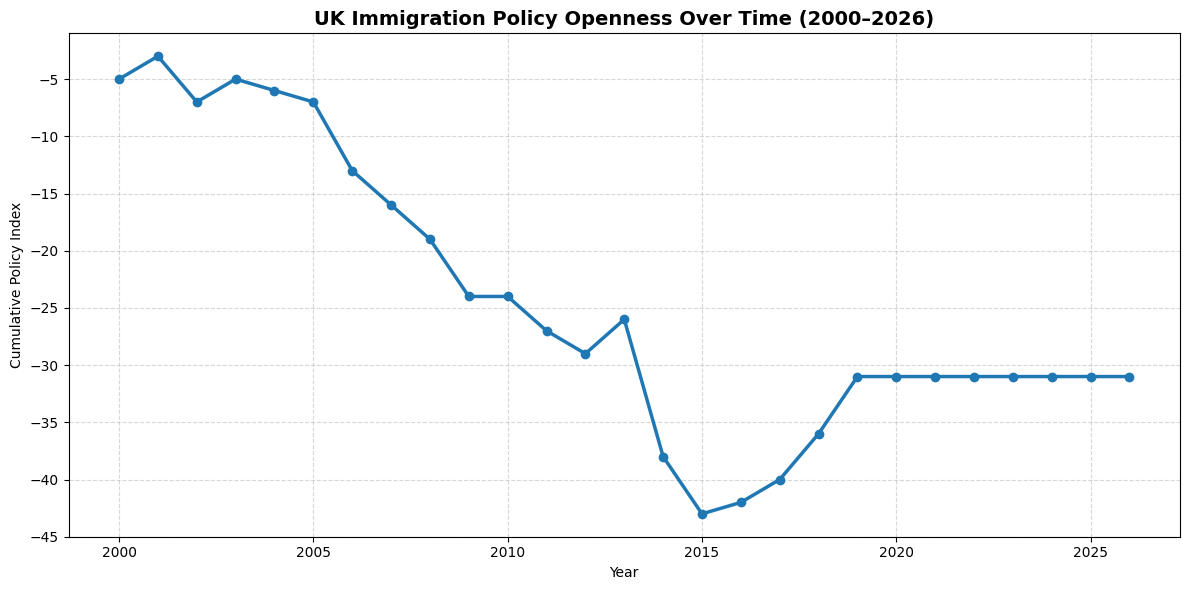

In [19]:
# =========================
# GRAPH 1: POLICY INDEX
# =========================

plt.figure(figsize=(12, 6))
plt.plot(policy_year["year"], policy_year["PolicyIndex"], marker="o", linewidth=2.5)
plt.title("UK Immigration Policy Openness Over Time (2000–2026)", fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Cumulative Policy Index")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### 4.1 UK Immigration Policy Trends

The cumulative policy index illustrates the evolution of UK immigration policy between 2000 and 2026.

The overall downward movement indicates a shift toward greater policy restrictiveness over time, especially between the late 2000s and mid-2010s. This suggests that immigration controls became tighter during this period.

From around 2019 onwards, the index becomes relatively stable, indicating fewer major policy shifts. Overall, the chart suggests that the UK has maintained a managed migration system with periods of tightening followed by stabilization.

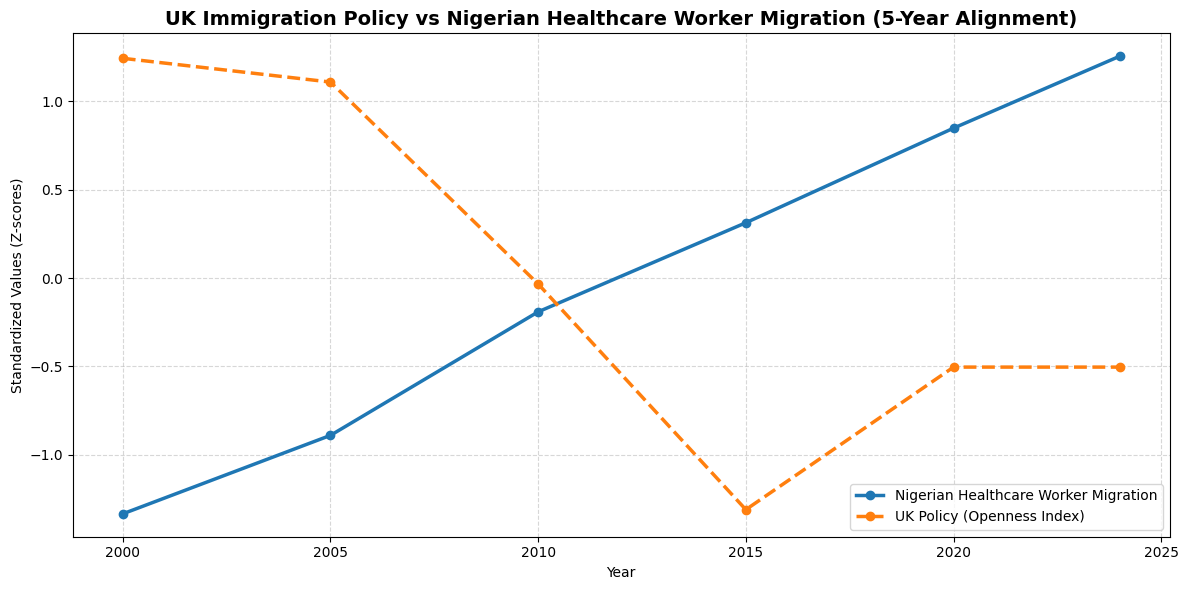

In [11]:
# =========================
# GRAPH 2: POLICY VS MIGRATION
# =========================

plt.figure(figsize=(12, 6))
plt.plot(
    merged_5yr["year"],
    merged_5yr["MedicalMigration_norm"],
    marker="o",
    linewidth=2.5,
    label="Nigerian Healthcare Worker Migration"
)

plt.plot(
    merged_5yr["year"],
    merged_5yr["Policy_norm"],
    marker="o",
    linewidth=2.5,
    linestyle="--",
    label="UK Policy (Openness Index)"
)

plt.title("UK Immigration Policy vs Nigerian Healthcare Worker Migration (5-Year Alignment)", fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Standardized Values (Z-scores)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### 4.2 Policy vs Nigerian Healthcare Worker Migration

The comparison between standardized policy openness and Nigerian healthcare worker migration shows a clear divergence in trends.

While the policy index becomes less open over time, migration continues to rise. This suggests that the migration of Nigerian healthcare workers is not solely determined by UK immigration policy.

The increase in migration despite periods of restriction points to the importance of other factors, particularly strong push factors in Nigeria and sustained labor demand in the UK healthcare sector. UK policy therefore appears to shape the conditions of entry, but not fully determine the overall direction of migration.

In [17]:
# =========================
# CORRELATION + SUMMARY
# =========================

correlation = merged_5yr[["Policy_norm", "MedicalMigration_norm"]].corr()
summary_stats = merged_5yr[["PolicyIndex", "MedicalMigration", "Policy_norm", "MedicalMigration_norm"]].describe()

print("Correlation matrix:")
print(correlation)

print("\nSummary statistics:")
print(summary_stats)

Correlation matrix:
                       Policy_norm  MedicalMigration_norm
Policy_norm               1.000000              -0.821628
MedicalMigration_norm    -0.821628               1.000000

Summary statistics:
       PolicyIndex  MedicalMigration  Policy_norm  MedicalMigration_norm
count     6.000000          6.000000     6.000000           6.000000e+00
mean    -23.500000     207588.833333     0.000000          -1.480297e-16
std      14.882876      92775.179238     1.000000           1.000000e+00
min     -43.000000      83822.000000    -1.310231          -1.334051e+00
25%     -31.000000     141214.000000    -0.503935          -7.154374e-01
50%     -27.500000     213225.000000    -0.268765           6.075080e-02
75%     -11.250000     273839.000000     0.823094           7.140937e-01
max      -5.000000     324007.000000     1.243039           1.254842e+00


### 5. Analysis

The results suggest that UK immigration policy functions more as an enabling or constraining framework than as the primary driver of migration.

The steady increase in Nigerian healthcare worker migration, even during periods of greater policy restriction, indicates that push factors in Nigeria are highly significant. These likely include limited professional opportunities, economic instability, and pressures within the domestic healthcare system.

At the same time, the UK continues to attract healthcare workers because of labor shortages and stronger employment opportunities. Migration patterns are therefore best understood as the result of an interaction between push factors in Nigeria, pull factors in the UK, and the policy environment that regulates movement.

### 6. Conclusion

This section shows that UK immigration policy influences the context in which migration occurs, but it does not independently determine the migration of Nigerian healthcare workers.

Migration trends continue upward even when policy becomes more restrictive, which highlights the importance of broader structural and economic factors. This suggests that healthcare worker migration should be understood as part of a wider global labor market dynamic rather than as a simple response to immigration policy alone.